## Introduction 


In the time period where information is rapidly disseminated through digital platforms, distinguishing between authentic news on what is real and a fake news or a misinformation has become a critical challenge. Fake news not only misleads the public but also hinders the social stability. This project addresses this issue by developing a transformer based deep learning model built entirely from scratch to detect fake news. Leveraging the power of attention mechanisms and contextual embeddings, the model will classify news articles as real or fake based on their textual content. By designing and implementing core components such as encoder blocks, token embeddings, and positional encodings, this project not only tackles a real world problem but also deepens the understanding of modern NLP architectures.

### Exploring the dataset

Dataset Shape -> (44898, 5)
label
0    23481
1    21417
Name: count, dtype: int64


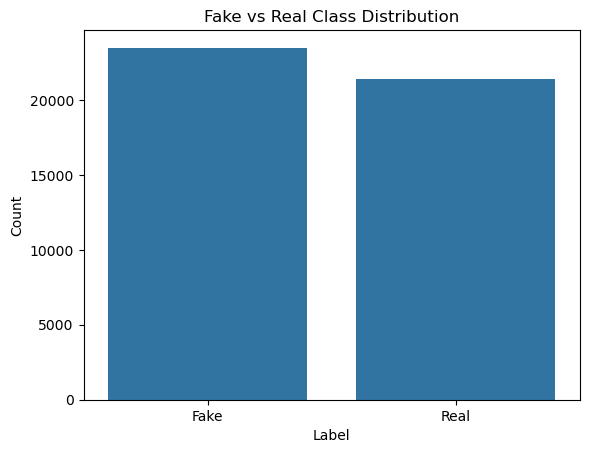

,title,text,label
18777,HEY “SIMPLETONS”…We’ve Got Great News! The Lef...,Lauren Southern is one tough reporter. She s n...,0
31225,Trump supporters tricked into buying beers at ...,MEXICO CITY (Reuters) - Supporters of U.S. Rep...,1
5091,Former Trump Staffer Suing After Campaign Dir...,A former staffer of Donald Trump s presidentia...,0


In [24]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the data
FakeData = pd.read_csv("data/Fake.csv")
RealData = pd.read_csv("data/True.csv")

# labeling Fake as 0 and Real as 1
FakeData["label"] = 0
RealData["label"] = 1

# Combine both the datasets
Dataset = pd.concat([FakeData, RealData], ignore_index=True)

# Dropping rows with missing values just in case if their are some
Dataset.dropna(subset=["title", "text"], inplace=True)

# Just a quick overview
print("Dataset Shape ->", Dataset.shape)
print(Dataset["label"].value_counts())

# Plotting the class balance
sns.countplot(x="label", data=Dataset)
plt.title("Fake vs Real Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks([0, 1], ["Fake", "Real"])
plt.show()

# View of few of the sample articles
Dataset.sample(3)[["title", "text", "label"]]


### Text Preprocessing


For this part of model the focus is on the following areas
- Combining the title and article text 
- Cleaning text that means removing special characters, lowercasing etc
- Tokenization
- Creating train-test splits

In [25]:
import re
from sklearn.model_selection import train_test_split

# Combining the title and the text
Dataset["FullText"] = Dataset["title"] + " " + Dataset["text"]

# function to clean text
def TextCleaning(text):
    text = text.lower()  # Lowercase all the characters first
    text = re.sub(r"\[.*?\]", "", text)  # Removing the text in brackets
    text = re.sub(r"http\S+|www\S+", "", text)  # Removing any URLs
    text = re.sub(r"<.*?>+", "", text)  # Removing any HTML tags
    text = re.sub(r"[^a-z\s]", "", text)  # Removing any punctuation and numbers
    text = re.sub(r"\s+", " ", text)  # Replacing multiple spaces with single space
    return text.strip()

# Applying this cleaning function to our dataset
Dataset["CleanedText"] = Dataset["FullText"].apply(TextCleaning)

# Quick preview
Dataset[["CleanedText", "label"]].sample(3)


,CleanedText,label
25346,house speaker ryan says daca fix border securi...,1
17914,wow top sponsors of nfl issue statements about...,0
6913,trump campaign manager wont be prosecuted for ...,0


### Splitting into training and testing sets

In [26]:
# Creating training and test splits with a split of 80% for train and 20% for test
training_texts, testing_texts, training_labels, testing_labels = train_test_split(
    Dataset["CleanedText"].values,
    Dataset["label"].values,
    test_size=0.2,
    random_state=42,
    stratify=Dataset["label"]
)

# Printing to verify
print("Training Samples ", len(training_texts))
print("Testing Samples:", len(testing_texts))


Training Samples  35918
Testing Samples: 8980


## Implementing the Transformer Model from scratch

#### Important Imports

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np


#### Token and Positional Embedding Layer

In Transformer models there's no concept of sequence order built into the architecture. Unlike RNNs or LSTMs, Transformers process the whole input at once so they need help in understanding the position of each token in the sequence.

This class does two key things:

- Token Embedding: Turns each word which is the token into a dense vector.
- Positional Embedding: Adds information about the position of each of the token so the model knows which token came first, second, etc.
  
The sum of these two embeddings is then passed into the transformer layers.


In [28]:
import torch
import torch.nn as nn

class TokenAndPositionalEmbedding(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_len=512):
        super(TokenAndPositionalEmbedding, self).__init__()
        
        # Token Embedding Layer: Learns a dense vector for each token
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        
        # Positional Embedding Layer: Learns a dense vector for each position index
        self.pos_embed = nn.Embedding(max_len, embed_dim)
    
    def forward(self, x):
        """
        x: Tensor of shape [batch_size, sequence_length]
        Each element in x is a token index that is an integer between 0 and vocab_size-1
        """
        
        # Get the positions for each token in the sequence.
        # For example, for a sequence length of 5, it returns: [[0, 1, 2, 3, 4]]
        positions = torch.arange(0, x.shape[1], device=x.device).unsqueeze(0)
        # Shape of positions: [1, sequence_length]

        # Get token embeddings and positional embeddings, then adds them
        token_embeddings = self.token_embed(x)         # Shape: [batch_size, sequence_length, embed_dim]
        position_embeddings = self.pos_embed(positions)  # Shape: [1, sequence_length, embed_dim]

        # Broadcast position embeddings to all batch elements and add them to token embeddings
        return token_embeddings + position_embeddings


#### Scaled Dot Product

This is the core of attention. This function calculates how much attention each word in a sequence should pay to the others based on similarity between words. It's the basic building block behind the self-attention mechanism.


This function lets each token dynamically focus on the relevant parts of the sequence when forming its new representation. It’s the core idea behind attention, thus enabling the model to understand context and meaning.


This function computes how much attention (focus) each token in a sequence should pay to other tokens. It:

* Takes in queries (Q), keys (K), and values (V).
* Computes similarity between Q and K using a dot product, scaled by √(key dimension) for stability.
* Optionally applies a mask to ignore certain positions like padding or future tokens
* Applies softmax to convert scores into attention weights like probabilities
* Uses these weights to calculate a weighted sum of values (V) — this is the final attention output
* The result is that each token gets a new representation which blends the relevant information from the entire sequence based on learned attention scores.

In [29]:
def scaled_dot_product_attention(q, k, v, mask=None):
    """
    Computes scaled dot-product attention.
    
    Args:
        q (Tensor): Query tensor of shape [batch_size, num_heads, seq_len, head_dim]
        k (Tensor): Key tensor of shape [batch_size, num_heads, seq_len, head_dim]
        v (Tensor): Value tensor of shape [batch_size, num_heads, seq_len, head_dim]
        mask (Tensor, optional): Attention mask of shape [batch_size, 1, seq_len, seq_len]. Default is None.
        q is What we’re trying to understand.
        k ia What we compare queries against.
        v is What we want to extract which is the final content.
        mask which is optional and is used to block certain tokens like padding or future tokens in decoder.
    
    Returns:
        Tuple:
            - Output tensor after attention applied to values (same shape as v)
            - Attention weights (for optional visualization or analysis)
    """
    
    # Get the dimensionality of the key query vectors 
    Dimensonality = q.size(-1) # This gets the dimension of each head, denoted as Dimensonality
    # This is used for scaling the dot product which is a key part of the "scaled" dot-product attention
    
    # Computing raw attention scores that is dot product of Q and K^T scaled by sqrt(Dimensonality)
    # Shape: [batch_size, num_heads, seq_len, seq_len]
    # For each query, I am computing the dot product with every key, this gives a score that measures similarity or relevance between the query and each key
    scores = torch.matmul(q, k.transpose(-2, -1)) / torch.sqrt(torch.tensor(Dimensonality, dtype=torch.float32, device=q.device))
    # Now we have a score matrix for how much each query token should pay attention to each key token

    # If a mask is provided like for padding or causal, then I apply it to the scores
    if mask is not None:
        # Set positions where mask == 0 to a large negative number so softmax becomes ~0
        scores = scores.masked_fill(mask == 0, float('-1e9')) #basically softmax(-1e9) ≈ 0.

    # Normalize the attention scores to probabilities using softmax along the last dimension
    # This gives us the attention weights
    attention = F.softmax(scores, dim=-1) 
    # Each query now has a probability distribution over all keys. These are called attention weights.

    # Multiply the attention weights with the values to get the final output
    # Shape: [batch_size, num_heads, seq_len, head_dim]
    output = torch.matmul(attention, v)

    # Return both the output and attention weights (useful for debugging or visualizing attention)
    return output, attention

#### Multi Head Attention Layer

The Multi-head attention layer is a core building block of the Transformer architecture. It allows the model to focus on different parts of the input sequence simultaneously, by splitting the attention mechanism into multiple "heads" that each learn different aspects of the relationships between tokens.

It achieves this by:

- Projecting the input into queries (Q), keys (K), and values (V).
- Splitting these into multiple heads and then computing attention for each of them
- Concatenating the outputs for all of the heads and projecting them back to the original embedding space

It allows the model to:

* Look at other tokens in the input sequence.
* Compute context-aware embeddings.
* Enable parallel processing

  
It helps the model understand how each token relates to others in the sequence.

Why multiple heads?

Each head will learn to focus on the different aspects of the input, like syntax in one head, sentiment in another, etc.



This layer allows each word or token in the input to look at other words and gather useful information about them, this is called self-attention. Instead of doing this once, multi-head attention does it multiple times in parallel like once per head, with different focuses or perspectives.


Without this, each word would be unaware about anything, about its context, like the words before or after it, this layer helps the model to

Learn which words matter for each position, and encode contextual meaning, that is crucial for tasks like translation, sentiment analysis and other

In [30]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadAttention, self).__init__()

        # Ensure that the embedding dimension is divisible by the number of heads, and each get an equal split
        assert embed_dim % num_heads == 0  

        self.num_heads = num_heads                    # Number of attention heads
        self.head_dim = embed_dim // num_heads        # Dimension of each head

        # One linear layer to simultaneously generate Q, K, V by projecting the input
        self.QKVLinear = nn.Linear(embed_dim, embed_dim * 3)
        # Why embed_dim * 3? 
        # I need three separate outputs of size embed dim each: one for Q, one for K, and one for V.
        # So, this layer learns three sets of weights, concatenated into one big matrix of shape [embed_dim, embed_dim * 3].

        # Final linear layer to combine the outputs of all heads
        self.OUTLinear = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        batch_size, seq_len, embed_dim = x.size()

        # Projecting input into query (Q), key (K), and value (V) tensors
        # Resulting shape: [batch_size, seq_len, 3 * embed_dim]
        qkv = self.QKVLinear(x)

        # Reshape to [batch_size, seq_len, 3, num_heads, head_dim]
        qkv = qkv.reshape(batch_size, seq_len, 3, self.num_heads, self.head_dim)# now I have Q, K, and V separated but still together in one tensor

        # Rearranging the dimensions to [3, batch_size, num_heads, seq_len, head_dim]
        qkv = qkv.permute(2, 0, 3, 1, 4)

        # Spliting into Q, K, V each of shape [batch_size, num_heads, seq_len, head_dim]
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Applying the previously created scaled dot-product attention
        out, _ = scaled_dot_product_attention(q, k, v)

        # Rearranging it back to [batch_size, seq_len, num_heads, head_dim]
        out = out.permute(0, 2, 1, 3)

        # Combining all the heads by flattening resulting in [batch_size, seq_len, embed_dim]
        out = out.reshape(batch_size, seq_len, embed_dim)

        # Final linear projection to mix head outputs
        return self.OUTLinear(out) # This layer then linearly transforms this combined tensor, essentially "mixing" information from all the heads

#### Feed Forward Network

This class represents a position wise feedforward neural network, which is a standard sublayer in a Transformer block. It's applied independently to each position or token in the sequence, after the attention mechanism.

In simple terms:

- Attention helps the model understand the relationships between tokens
- Feedforward layers then transform each of the token's embedding further to improve learning capacity

What does it do?

For each of the token's embedding the feedforward network applies:

- A linear transformation 
- A non-linear activation 
- Another linear transformation.
  
This allows the model to:

- Capture non-linear relationships.
- Add depth and flexibility.
- Refine each token’s internal representation which is based on what it learned via attention

In [31]:
class FeedForward(nn.Module):
    def __init__(self, embed_dim, hidden_dim):
        super(FeedForward, self).__init__()
        
        # First fully connected (linear) layer
        # Takes input of size [batch_size, seq_len, embed_dim]
        # and outputs size [batch_size, seq_len, hidden_dim]
        self.Linear1 = nn.Linear(embed_dim, hidden_dim)
        # First linear layer projects input from embedding dimension to a higher hidden dimension
        # This allows the model to learn richer and more abstract features

        # Second fully connected layer
        # Takes input of size [batch_size, seq_len, hidden_dim]
        # and outputs size [batch_size, seq_len, embed_dim]
        self.Linear2 = nn.Linear(hidden_dim, embed_dim)
       
        # Second linear layer projects from hidden dimension back to the embedding dimension
        # This ensures that the output has the same shape as the input so it can be added to residual connections

    
    def forward(self, x):
       # x: [batch_size, sequence_length, embed_dim]
        
        # Applying the first linear transformation
        # Expanding each token's representation to a larger hidden space
        x = self.Linear1(x)

        # Applying non-linearity (ReLU)
        # Without this, the network would behave like a single-layer linear model that is limited to learning power

        x = F.relu(x)

        # Applying the second linear transformation
        # Bringing back the data to its original embedding size, so it can be combined with residuals or used by next layers
        x = self.Linear2(x)

        return x

#### Encoder Block

This is a single transformer encoder block that is used primarily in natural language processing (NLP) tasks to understand and encode input sequences (like sentences or documents) into meaningful numerical representations.

My model deals with natural language input (like sentences) and is based on the Transformer encoder architecture. The EncoderBlock plays a vital role in transforming the raw token embeddings into contextualized representations, which is turning a sequence of word embeddings into a form where each of the word understands its relationship with the others in the sequence.
It encodes relationships in the input text, which is essential for downstream tasks like classification, translation, summarization.

In [21]:
# A Transformer Encoder Block
class EncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, dropout=0.1):
        super(EncoderBlock, self).__init__()

        # Multi-head self-attention layer
        self.attention = MultiHeadAttention(embed_dim, num_heads)
        # This is the Multi-Head Attention layer that is allowing the model to attend to different words for each word it helps the model capture different relationships like subject-verb-object, co-reference

        # Feed-forward network (two linear layers with ReLU in between)
        self.feedForward = FeedForward(embed_dim, ff_hidden_dim)
        # Applied independently to each position after attention.
        # It helps in learning non linear transformations of the attended embeddings.

        #  These are two Layer Normalization modules
        # These are essential for stabilizing the learning process
        # they are applied after each major sub block that is attention and FFN
        self.Normalization1 = nn.LayerNorm(embed_dim)
        self.Normalization2 = nn.LayerNorm(embed_dim)

        # Dropout helps in regularizing the model by randomly turning off some units during training
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # --- 1. Multi-head self-attention with residual connection and layer norm ---

        # Output is the same shape as input: [batch, seq_len, embed_dim], but now each token knows more about its context
        attention_out = self.attention(x)                        # Self-attention output
        # Applying residual connection, then applying dropout and layer normalization, which helps preserving original features while enhancing with attention output
        x = self.Normalization1(x + self.dropout(attention_out))     

        # --- 2. Feed-forward layer with residual connection and layer norm ---
        # Passing the result through the feed forward network
        # This lets the model transform the context aware representation into a higher level of abstraction
        feedForward_out = self.feedForward(x)                          # Feed-forward output

        # Another residual connection + dropout + normalization ensures the model remains stable and learns deeply.
        x = self.Normalization2(x + self.dropout(feedForward_out))      

        return x


### Building the Custom Transformer Encoder

this is the final step of the transformer model

This class defines a complete Transformer-based model that:

- Takes in tokenized text input,
- Embeds the tokens and positions,
- Passes them through multiple Transformer Encoder blocks,
- Extracts a meaningful sentence representation which is usually done using the first token
- Passes it through a feedforward classifier head to predict a label like real or fake


This class gives a complete, modular, and powerful Transformer based model for any classification task, It is:

- Fully scalable like i can change the depth, width
- End-to-end learnable
- Great for language understanding and feature extraction

In [32]:
class TransformerEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=4, ff_hidden_dim=256, num_layers=2, max_len=512, num_classes=2):
        super(TransformerEncoderClassifier, self).__init__()

        # These parameters let us control the architecture — for instance, how wide the embeddings are, how deep the model is and how many output classes to predict

        # Step 1: Combining token embedding and positional embedding

        # Transformers don’t have recurrence or convolution, so they need positional embeddings to understand the token order, this layer ensures each word is represented both by its meaning (token) and its position in the sentence.

        
        self.embedding = TokenAndPositionalEmbedding(vocab_size, embed_dim, max_len) # This line cteates a layer to embed tokens and add positional encoding
        # it combines word meaning which is token embedding + position which is positional embedding), and the output shape is batch_size, seq_len, embed_dim]

        # Step 2: Stacking multiple Transformer Encoder blocks

        # Transformers build deep context by stacking multiple layers so each EncoderBlock refines the representation by allowing each token to attend to others. The list lets us apply n blocks in a sequence

        # It creates a list of EncoderBlocks (like a Transformer stack) and each block:

        # Applies a multi-head self-attention
        # Applies a feedforward network
        # Normalizes and applies residual connections
        
        self.encoder_layers = nn.ModuleList([
            EncoderBlock(embed_dim, num_heads, ff_hidden_dim) for _ in range(num_layers)
        ])

        # Step 3: Classification head - takes encoded representation and outputs class logits
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),  # Project to a hidden layer
            nn.ReLU(),                            # Adds non-linearity
            nn.Dropout(0.2),                       # Regularization
            nn.Linear(ff_hidden_dim, num_classes) # Output logits 
        )

    def forward(self, x):
        # Input x shape: [batch_size, sequence_length] (token ids)

        # Step 1: Embed tokens + add positional information
        # Transformers can't process raw indices so this prepares the input for attention by encoding semantic and syntactic information
        x = self.embedding(x)  # Shape: [batch_size, seq_len, embed_dim], here each token is turned into vector

        # Step 2: Pass through N encoder blocks (self-attention + feedforward)
        # Each block deepens the understanding by letting each token attend to others and refining its meaning based on full context, therefore more layers = more abstraction
        for layer in self.encoder_layers:
            x = layer(x)  # Shape remains the same
        # this step passes the embeddings through each encoder block (stacked Transformer layers) and each block allows contextual understanding via self-attention.

        # Step 3: Extracting the first token's representation as the sentence vector
        # In many Transformer models the first token is a special token like [CLS] which is meant to represent the entire sentence 
        # Basically it uses first token’s output as a sentence embedding
        cls_representation = x[:, 0, :]  # Shape: [batch_size, embed_dim]

        # it uses the output vector of the first token (x[:, 0, :]) as the sentence representation, It assumes this first token carries information about the entire sentence after attention.
        # x[:, 0, :] extracts that for every sample in the batch


        # Step 4: Pass through classifier head to get logits
        return self.classifier(cls_representation)  # Output: [batch_size, num_classes]


### Tokenization and Preprocessing


I am now setting up the data preprocessing pipeline for training the Transformer model, it is kind of a prerequisite 

The Summary is

- Tokenization: Splits raw text into words.
- Vocabulary Building: Constructs a dictionary of common words with indices.
- Text Encoding: Converts words into fixed-length numeric vectors using the vocabulary.
- Dataset Class: Wraps the data and prepares it for PyTorch training.
- DataLoader: Efficiently feeds data in batches to the model during training/testing.

In [33]:
# Importing Required Libraries
import re                                  # Regular expressions 
import torch                               # PyTorch main package
from torch.utils.data import Dataset, DataLoader  # Dataset and DataLoader for handling the data efficiently in batches
from collections import Counter            # Used for counting token frequencies
from sklearn.model_selection import train_test_split  # To split the data into training and testing sets

# 1. Tokenization Function

def tokenize(text):
    # Splits a given text string into a list of tokens based on the whitespace
    # Very basic tokenization because text cleaning is done prior
    return text.split()

# 2. Vocabulary Building Function


def build_vocab(texts, max_vocab_size=10000, min_freq=2):
    # Builds a vocabulary dictionary from a list of text documents.
    # it includes only those words that appear at least min_freq times,
    # and limits the total size to max_vocab_size

    counter = Counter()  # Counter object to keep a track of word frequencies

    for text in texts:
        tokens = tokenize(text)  # Tokenize each input text
        counter.update(tokens)   # Count frequencies of each token

    # Initializing the vocabulary with special tokens
    # <PAD>: for padding, <UNK>: for unknown/out-of-vocabulary words
    vocab = {"<PAD>": 0, "<UNK>": 1}

    # Adding most frequent words to the vocab, respecting min_freq and size limit
    for word, freq in counter.most_common(max_vocab_size - 2):  # -2 to account for <PAD> and <UNK>
        if freq >= min_freq:
            vocab[word] = len(vocab)  # Assigning next available index to word

    return vocab  # Returning the constructed vocab as a dictionary (word -> index)


# 3. Text Encoding Function 


def encode_text(text, vocab, max_len=512):
    # Converts a text string into a fixed length list of token indices
    # using the provided vocabulary. Pads shorter sequences with <PAD>,
   

    tokens = tokenize(text)  # Tokenize the input text
    # Converting these tokens to their corresponding indices in the vocab
    encoded = [vocab.get(token, vocab["<UNK>"]) for token in tokens[:max_len]]

    # Pad with <PAD> index if encoded length is less than max_len
    if len(encoded) < max_len:
        encoded += [vocab["<PAD>"]] * (max_len - len(encoded))  # Padding

    return encoded  # Final list of size max_len containing token indices


# 4. Custom Dataset Class for PyTorch




class NewsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=512):
        # Store the texts, labels, vocabulary, and max_len as instance variables
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        # Returns the total number of samples in the dataset
        return len(self.texts)

    def __getitem__(self, idx):
        # Gets a single (encoded_text, label) pair at the specified index
        text = self.texts[idx]                    # Fetch text at index
        label = self.labels[idx]                  # Fetch corresponding label
        encoded = encode_text(text, self.vocab, self.max_len)  # Encode the text
        return torch.tensor(encoded), torch.tensor(label)      # Convert both to PyTorch tensors


# 5. Vocabulary Creation
# Build vocabulary using the training text

vocab = build_vocab(training_texts, max_vocab_size=10000)


# 6. Dataset Creation
# Creates PyTorch datasets from training and testing data


train_dataset = NewsDataset(training_texts.tolist(), training_labels.tolist(), vocab)
test_dataset = NewsDataset(testing_texts.tolist(), testing_labels.tolist(), vocab)

# 7. DataLoader Setup

# Creates a DataLoader to handle mini-batches and shuffling

train_loader = DataLoader(
    train_dataset,        # Use the training dataset
    batch_size=32,        # Number of samples per batch
    shuffle=True          # Shuffle training data for better learning
)

test_loader = DataLoader(
    test_dataset,         # Use the test dataset
    batch_size=32,        # Batch size for evaluation
    shuffle=False         # No need to shuffle test data
)
 

### Model Training

the whole process of model training is
- Data is loaded in batches and converted into tensors.
- The model embeds the text and runs it through Transformer encoder blocks.
- It then outputs logits for each class.
- The loss compares the predicted logits with actual labels.
- Backpropagation then computes how much to change weights.
- The optimizer updates the weights to reduce future loss.
- After each epoch, accuracy and loss are printed.

In [34]:
# Importing required libraries

import torch.optim as optim                     # Provides an optimizers like Adam
import torch.nn.functional as F                 # Functional API which is optional in this script
import matplotlib.pyplot as plt                 # For plotting loss/accuracy 
from tqdm import tqdm                           # Provides a nice progress bar for loops


# Configure device, it should use GPU if available, otherwise fall back to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the Transformer based classifier model and move it to the selected device
model = TransformerEncoderClassifier(vocab_size=len(vocab), embed_dim=128, num_heads=4, ff_hidden_dim=256, num_layers=2, num_classes=2).to(device)

# the arguments used are
# Size of vocabulary the number of unique tokens
# Dimension of the token embeddings
# Hidden layer size in the feed forward network
# Number of encoder layers which are stacked
# Number of output classes which is 2 as it is a binary classification real or fake
# Move the model to GPU or CPU

# Defining the loss function and optimizer

criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss is used for classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam optimizer adjusts learning during training

# Lists to store loss and accuracy after each epoch for future plotting

epoch_losses = [] # Tracks the average training loss per epoch
epoch_accuracies = []  # Tracks the training accuracy per epoch

# Training Loop
epochs = 5 # Number of times the model sees the entire dataset, which is 5

for epoch in range(epochs):
    model.train()  # Puts the model in training mode therefore enables dropout and layer norm updates
    running_loss = 0.0 # the cumulative loss for this epoch
    correct = 0.0      # the number of correct predictions
    total = 0          # the total number of predictions made
    
    # Progress bar for training, and looping through the data loader one batch at a time
    
    for batch_idx, (data, targets) in enumerate(tqdm(train_loader)):
        
        # Moving the input tensors to the same device as the model
        data, targets = data.to(device), targets.to(device)
        
       # Resetting all the gradients from the previous backward pass
        optimizer.zero_grad()
        
        # Forward pass, feed input to model to get predictions 
        outputs = model(data)
        
        # Calculate the loss
        loss = criterion(outputs, targets)
        
        # Backward pass, compute the gradients with respect to the loss
        loss.backward()

        # Updating the model parameters using the optimizer
        optimizer.step()
        
        # Accumulating the batch loss
        running_loss += loss.item()
        
        # Getting the predicted class by selecting the class with highest logit score
        
        _, predicted = torch.max(outputs, 1)  # Getd the index of the max log-probability

        # Counts the total and correct predictions for calculating accuracy
        total += targets.size(0)    # Total number of labels in the batch
        correct += (predicted == targets).sum().item()  # Increment correct count

    # Calculating average loss and accuracy for the epoch
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total
    
    # Storing this loss and accuracy for plotting
    epoch_losses.append(epoch_loss)
    epoch_accuracies.append(epoch_accuracy)

    # Print epoch results
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")
 

  2%|▏         | 27/1123 [00:12<08:24,  2.17it/s]


KeyboardInterrupt: 

### Model Evaluation

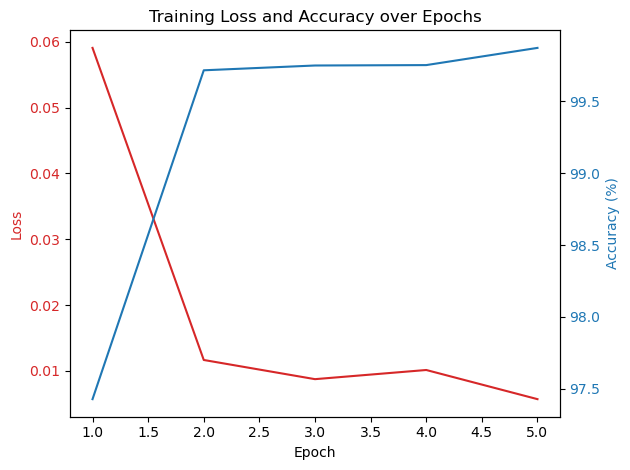

In [ ]:
# Plot Loss and Accuracy over Epochs
fig, ax1 = plt.subplots()  # Creating a figure and a set of subplots which is only 1 subplot here

# (Left Y-axis) 
ax1.set_xlabel('Epoch')  # Set x-axis label
ax1.set_ylabel('Loss', color='tab:red')  # Set y-axis label for loss with red color
ax1.plot(range(1, epochs+1), epoch_losses, color='tab:red', label='Loss')  # Plot loss values over epochs
ax1.tick_params(axis='y', labelcolor='tab:red')  # Set tick color for y-axis to red

# Plotting Accuracy (Right Y-axis)
ax2 = ax1.twinx()  # Creating a second y-axis sharing the same x-axis
ax2.set_ylabel('Accuracy (%)', color='tab:blue')  # Set y-axis label for accuracy with blue color
ax2.plot(range(1, epochs+1), epoch_accuracies, color='tab:blue', label='Accuracy')  # Plot accuracy values over epochs
ax2.tick_params(axis='y', labelcolor='tab:blue')  # Set tick color for second y-axis to blue


plt.title('Training Loss and Accuracy over Epochs')  # Add title to the plot
plt.tight_layout()  # Adjust subplot spacing to avoid overlap
plt.show()  # Display the plot


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score  # Import evaluation metrics

# Set the model to evaluation mode 
model.eval()

# Lists to store all predicted and actual labels
predicted_labels = []
actual_labels = []

# Disable gradient calculation (for inference only)
with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device)      # Move input data to GPU/CPU
        batch_labels = batch_labels.to(device)      # Move labels to GPU/CPU

        # Forward pass: compute model outputs
        logits = model(batch_inputs)

        # Convert raw logits to predicted class labels
        _, predicted_classes = torch.max(logits, dim=1)

        # Append to lists (moving back to CPU and converting to numpy)
        predicted_labels.extend(predicted_classes.cpu().numpy())
        actual_labels.extend(batch_labels.cpu().numpy())

# Compute evaluation metrics
test_accuracy = accuracy_score(actual_labels, predicted_labels)
test_precision = precision_score(actual_labels, predicted_labels, average='binary')  # Using 'macro' if multiclass
test_recall = recall_score(actual_labels, predicted_labels, average='binary')
test_f1 = f1_score(actual_labels, predicted_labels, average='binary')

# Display the results
print(f"Test Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Precision:      {test_precision:.4f}")
print(f"Recall:         {test_recall:.4f}")
print(f"F1 Score:       {test_f1:.4f}")


Test Accuracy:  99.84%
Precision:      1.0000
Recall:         0.9967
F1 Score:       0.9984


## Final Overview

This Transformer Encoder model is performing near perfect classification. Very few misclassifications exist. Precision being higher than the recall means that the model is conservative with positive predictions, and only labeling samples as positive when very confident.


High F1 Score confirms that this balance is not at the cost of either precision or recall



Such high scores are ideal when:
- I am dealing with binary classification which in this case I am.
- Both the false positives and false negatives are costly, for example in news classification, spam detection, or sentiment analysis

  
the model is performing at near state of the art levels on this task. If this is real-world data then it means that 

- The data is well-cleaned and meaningful.
- The model architecture is highly effective.
- No major overfitting is visible from these test metrics.